In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.datasets import MNIST
import torchvision.transforms as transforms

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'

In [3]:
class autoencoderMLP4Layer(nn.Module):

    def __init__(self, N_input=784, N_bottleneck=8, N_output=784):
        super(autoencoderMLP4Layer, self).__init__()
        N2 = 392
        self.fc1 = nn.Linear(N_input, N2)       # input = 1x784, output = 1x392
        self.fc2 = nn.Linear(N2, N_bottleneck)  # output = 1xN
        self.fc3 = nn.Linear(N_bottleneck, N2)  # output = 1x392
        self.fc4 = nn.Linear(N2, N_output)      # output = 1x784
        self.type = 'MLP4'
        self.input_shape = (1, 28 * 28)

    def encode(self, X):
        # encoder
        X = self.fc1(X)
        X = F.relu(X)
        X = self.fc2(X)
        X = F.relu(X)
        return X

    def decode(self, X):
        # decoder
        X = self.fc3(X)
        X = F.relu(X)
        X = self.fc4(X)
        X = torch.sigmoid(X)
        return X
    
    def forward(self, X):
        return self.decode(self.encode(X))

In [4]:
def interpolateImages(model, img1, img2, n):
    bottleneck1 = model.encode(img1)
    bottleneck2 = model.encode(img2)
    bottleneckTensors = []
    for alpha in torch.linspace(0, 1, n):
        interpolatedBottleneck = (1 - alpha) * bottleneck1 + alpha * bottleneck2
        output = model.decode(interpolatedBottleneck)
        bottleneckTensors.append(output)
    return bottleneckTensors

In [5]:
train_transform = transforms.Compose([transforms.ToTensor()])
train_set = MNIST('./data/mnist', train=True, download=True, transform=train_transform)

In [6]:
model = autoencoderMLP4Layer(N_input=784, N_bottleneck=8, N_output=784)
model.load_state_dict(torch.load('MLP.8.pth', map_location=device))
model.to(device)
model.eval()

autoencoderMLP4Layer(
  (fc1): Linear(in_features=784, out_features=392, bias=True)
  (fc2): Linear(in_features=392, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=392, bias=True)
  (fc4): Linear(in_features=392, out_features=784, bias=True)
)

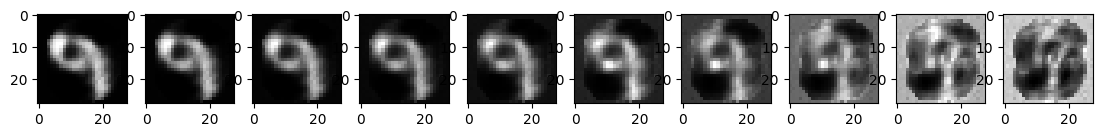

In [7]:
randIdx = torch.randint(0, len(train_set.data), (1,)).item()

img1 = train_set.data[randIdx]
img1 = img1.type(torch.float32)
img1 = (img1 - torch.min(img1)) / torch.max(img1)
img1 = img1.to(device)
img1 = img1.view(1, -1).type(torch.FloatTensor)

img2 = train_set.data[randIdx]
img2 = img2.type(torch.float32)
img2 = (img1 - torch.min(img2)) / torch.max(img2)
img2 = img2.to(device)
img2 = img2.view(1, -1).type(torch.FloatTensor)

interpolatedImages = interpolateImages(model, img1, img2, 10)

plt.figure(figsize=(15, 3))
for i, img in enumerate(interpolatedImages):
    plt.subplot(1, len(interpolatedImages) + 1, i + 1)
    plt.imshow(img.detach().numpy().reshape(28, 28), cmap='gray')